# 2D Ising Model Score-Based Generative Modeling

This notebook creates 2D Ising model spin configurations at a fixed temperature by training a Diffusion Model (via Score Matching).



Binary spins $\sigma_i \in \{-1, +1\}$ on a square lattice make up the 2D Ising model. At the crucial temperature $T_c \approx 2.269$, it experiences a ferromagnetic phase change.

* The magnetization's probability distribution, $m = \frac{1}{N}\sum \sigma_i$, is
* This intricate, split probability landscape must be learned by our generative model!


With a cosine noise schedule, we employ a **variance-preserving SDE**: $x_t = \alpha(t)x_0 + \beta(t)\epsilon$.
We employ the **$v$-parameterization** to increase numerical stability close to $t \to 0$, where the continuous mathematical variables need to snap into discrete physical spins:
$$v = \alpha(t)\epsilon - \beta(t)x_0$$



In [ ]:
import math
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

# -----------------------
# Configuration & Hyperparameters
# -----------------------
SEED = 0
T_TRAIN_RAW = 2.5 #[0.25,0.5,0.75,1.,1.25,1.5,1.75,2.,2.25,2.5,2.75,3.,3.25,3.5,3.75,4. ]
T_MIN, T_MAX = 0.25, 4.0 #temprature max and min of dataset
GRID = 40
DIM = GRID * GRID

BATCH_SIZE = 256
EPOCHS = 50
LR = 1e-4
EMA_BETA = 0.999 #Exponential Moving Average beta for stable generation
GRAD_CLIP = 1.0

SAMPLE_N = 64 #num of sample to generate
SAMPLE_STEPS = 100 #diffusion steps
ETA = 0.5 #0 is deterministic 1 is stochastic
DISCRETIZE = "end_sign"  # "end_sign" | "tanh_anneal" | "stochastic_end" # Method to force continuous floats to -1 or 1

# -----------------------
# Reproducibility Setup
# -----------------------
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


Before executing this cell, ensure that `output_array.npy` has been uploaded to your Colab environment.

To ensure that the neural network only sees data for a give T, we extract the data, translate the {$0, 1$} binary states to $\{-1, +1\}$ physical spins, and filter the dataset.

In [ ]:
# Loads binary spin configurations from .npy file and converts {0,1} → {-1,+1}
# Data is organized by temperature blocks with shuffling within each temperature
"""filename: Path to .npy file containing uint8 packed binary spin data

    Returns:
        X: Spin configurations as {-1, +1} floats, shape (N, DIM)
        Y: Temperature labels for each sample
    """
def load_data(filename="output_array.npy"):
    data = np.load(filename)


    if data.dtype == np.uint8:
        X_all = np.unpackbits(data).astype(np.float32).reshape(-1, DIM)
    else:
        X_all = data.astype(np.float32).reshape(-1, DIM)

    temps = np.arange(0.25, 4.01, 0.25)
    num_samples_per_temp = X_all.shape[0] // len(temps)
    Y_all = np.repeat(temps, num_samples_per_temp)

    # Shuffle within each temperature block
    X_shuffle_blocks, Y_shuffle_blocks = [], []
    for i, t in enumerate(temps):
        start, end = i * num_samples_per_temp, (i + 1) * num_samples_per_temp
        idx = np.random.permutation(num_samples_per_temp)
        X_shuffle_blocks.append(X_all[start:end][idx])
        Y_shuffle_blocks.append(Y_all[start:end][idx])

    X = np.vstack(X_shuffle_blocks)
    Y = np.concatenate(Y_shuffle_blocks)

    # Convert spins {0,1} -> {-1,+1}
    X = 2.0 * X - 1.0
    return X, Y

X_all, Y_all = load_data("output_array.npy")

mask = np.isclose(Y_all, T_TRAIN_RAW, atol=1e-6)
assert mask.any(), f"No samples at T={T_TRAIN_RAW}. Available: {np.unique(Y_all)}"

X = X_all[mask].astype(np.float32)  # (N_T,1600)
temp_scaled = float(np.clip((T_TRAIN_RAW - T_MIN) / (T_MAX - T_MIN), 0.0, 1.0))
Y_scaled = np.full((len(X), 1), temp_scaled, dtype=np.float32)

print(f"Train set @ T={T_TRAIN_RAW}: {X.shape[0]} samples.")

dataset = TensorDataset(
    torch.tensor(X, dtype=torch.float32),
    torch.tensor(Y_scaled, dtype=torch.float32),
)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

Train set @ T=2.5: 10000 samples.


We employ a **Conditional U-Net** to learn the thermodynamic forces.
Importantly, `padding_mode="circular" is used in the convolutional layers. By enforcing periodic boundary requirements, the neural network is guaranteed to adhere to the physics of the infinite 2D lattice.

In [ ]:
# Conditional U-Net with circular padding to enforce periodic boundary conditions
# Critical for respecting the physics of the infinite 2D Ising model


class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim: int):
        super().__init__()
        self.dim = dim

    def forward(self, time: torch.Tensor) -> torch.Tensor:
        half = self.dim // 2
        freqs = math.log(10000) / (half - 1)
        freqs = torch.exp(torch.arange(half, device=time.device) * -freqs)
        args = time * freqs[None, :]
        return torch.cat([args.sin(), args.cos()], dim=-1)
 """
    Double convolution block with GroupNorm and GELU activation.
    Uses circular padding to maintain periodic boundary conditions.
    """
class DoubleConv(nn.Module):
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, padding_mode="circular"),
            nn.GroupNorm(8, out_ch),
            nn.GELU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, padding_mode="circular"),
            nn.GroupNorm(8, out_ch),
            nn.GELU(),
        )

    def forward(self, x):
        return self.net(x)
 """
    Conditional U-Net for score matching on Ising model configurations.

    Architecture: Encoder-Decoder with skip connections
    - Time and temperature conditioning injected at bottleneck
    - Circular padding ensures translation invariance (infinite lattice physics)
    """
class UNetIsingCond(nn.Module):
    def __init__(self, grid_size=40, base_dim=64):
        super().__init__()
        self.grid_size = grid_size
        emb_dim = base_dim * 4

        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(emb_dim),
            nn.Linear(emb_dim, emb_dim),
            nn.GELU(),
        )
        self.temp_mlp = nn.Sequential(
            nn.Linear(1, emb_dim),
            nn.GELU(),
            nn.Linear(emb_dim, emb_dim),
        )

        self.down1 = DoubleConv(1, base_dim)
        self.pool1 = nn.MaxPool2d(2)
        self.down2 = DoubleConv(base_dim, base_dim * 2)
        self.pool2 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(base_dim * 2, base_dim * 4)

        self.up1 = nn.ConvTranspose2d(base_dim * 4, base_dim * 2, 2, stride=2)
        self.upc1 = DoubleConv(base_dim * 4, base_dim * 2)

        self.up2 = nn.ConvTranspose2d(base_dim * 2, base_dim, 2, stride=2)
        self.upc2 = DoubleConv(base_dim * 2, base_dim)

        self.final = nn.Conv2d(base_dim, 1, kernel_size=1)

    def forward(self, x_vec, t, temp):
        B = x_vec.shape[0]
        x = x_vec.view(B, 1, self.grid_size, self.grid_size)
        emb = (self.time_mlp(t) + self.temp_mlp(temp)).view(B, -1, 1, 1)

        d1 = self.down1(x)
        p1 = self.pool1(d1)
        d2 = self.down2(p1)
        p2 = self.pool2(d2)

        b = self.bottleneck(p2) + emb

        u1 = self.up1(b)
        u1 = torch.cat([u1, d2], dim=1)
        u1 = self.upc1(u1)

        u2 = self.up2(u1)
        u2 = torch.cat([u2, d1], dim=1)
        u2 = self.upc2(u2)

        out = self.final(u2)
        return out.view(B, -1)

class EMA:
    def __init__(self, beta=0.999):
        self.beta = beta

    @torch.no_grad()
    def update(self, ema_model: nn.Module, model: nn.Module):
        for p, p_ema in zip(model.parameters(), ema_model.parameters()):
            p_ema.data.mul_(self.beta).add_(p.data, alpha=1 - self.beta)

def hard_sign(x: torch.Tensor) -> torch.Tensor:
    s = torch.sign(x)
    s[s == 0] = 1
    return s

The forward SDE (injecting noise) is defined by the `train_score` function. The opposite procedure (data generation) is defined by the `sample_score_ddim` function.
To reintroduce controlled stochasticity into the sampling process, we employ the deterministic DDIM update rule with $\eta$.

In [ ]:
def alpha_beta_cosine(t: torch.Tensor):
    alpha = torch.cos((math.pi / 2) * t)
    beta = torch.sin((math.pi / 2) * t)
    return alpha, beta
"""
    Train score model using v-parameterization and denoising score matching.

    The v-parameterization predicts v = α(t)ε - β(t)x_0, which is more
    numerically stable near t→0 compared to predicting noise or x_0 directly.

    Args:
        model: U-Net score model
        dataloader: Training data loader
        epochs: Number of training epochs
        lr: Learning rate
        ema_beta: EMA decay factor
        grad_clip: Gradient clipping norm

    Returns:
        model: Trained model
        ema_model: EMA version of model (best for sampling)
        loss_hist: Training loss history
    """
def train_score(model: nn.Module, dataloader, epochs=50, lr=1e-4, ema_beta=0.999, grad_clip=1.0):
    model = model.to(device)
    ema_model = copy.deepcopy(model).to(device).eval()
    for p in ema_model.parameters():
        p.requires_grad_(False)

    ema = EMA(beta=ema_beta)
    opt = optim.Adam(model.parameters(), lr=lr)
    lr_sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    mse = nn.MSELoss()

    loss_hist = []
    for ep in range(epochs):
        model.train()
        total = 0.0
        for x0, temp in dataloader:
            x0, temp = x0.to(device), temp.to(device)

            B = x0.size(0)
            t = torch.rand(B, 1, device=device) * 0.995 + 0.0025
            a, b = alpha_beta_cosine(t)

            eps = torch.randn_like(x0)
            x_t = a * x0 + b * eps

            # The v-parameterization target
            v_target = a * eps - b * x0
            v_pred = model(x_t, t, temp)

            loss = mse(v_pred, v_target)

            opt.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            opt.step()

            ema.update(ema_model, model)
            total += loss.item()

        lr_sched.step()
        avg = total / len(dataloader)
        loss_hist.append(avg)

        if ep == 0 or (ep + 1) % 10 == 0:
            print(f"[SCORE vpred] epoch {ep+1:03d}/{epochs} loss={avg:.6f}")

    return model, ema_model, loss_hist

"""
    Generate samples using DDIM sampling with controllable stochasticity.

    DDIM provides deterministic sampling when η=0, and adds stochasticity
    when η>0. This allows trading off sample diversity vs quality.

    Args:
        ema_model: EMA-smoothed score model
        T_raw: Target temperature for generation (can differ from training T)
        n: Number of samples to generate
        steps: Number of denoising steps
        eta: Stochasticity parameter (0=deterministic, 1=full DDPM-like)
        discretize: Method to convert continuous → discrete spins
        tanh_k_min/max: Annealing parameters for tanh discretization

    Returns:
        spins: Generated spin configurations as {-1, +1} numpy array
    """

@torch.no_grad()
def sample_score_ddim(ema_model: nn.Module, T_raw: float, n=16, steps=200, eta=0.9, discretize="end_sign", tanh_k_min=1.0, tanh_k_max=20.0): # Default is eta=0.5
    ema_model.eval()
    dev = next(ema_model.parameters()).device

    temp_scaled = float(np.clip((T_raw - T_MIN) / (T_MAX - T_MIN), 0.0, 1.0))
    temp = torch.full((n, 1), temp_scaled, device=dev)

    x = torch.randn(n, DIM, device=dev)
    t_max, t_min = 0.9975, 0.0025
    ts = torch.linspace(t_max, t_min, steps + 1, device=dev).view(-1, 1)

    for i in range(steps):
        t, t_prev = ts[i].expand(n, 1), ts[i + 1].expand(n, 1)
        a, b = alpha_beta_cosine(t)
        a_prev, b_prev = alpha_beta_cosine(t_prev)

        v_pred = ema_model(x, t, temp)

        # Recover clean data and noise algebraically from v
        x0_pred = (a * x - b * v_pred).clamp(-1.0, 1.0)
        eps_pred = b * x + a * v_pred

        ab, ab_prev = (a**2).clamp(1e-8, 1.0), (a_prev**2).clamp(1e-8, 1.0)

        # DDIM update rule
        sigma = eta * torch.sqrt((1 - ab_prev) / (1 - ab)) * torch.sqrt(1 - ab / ab_prev)
        sigma = sigma.clamp(min=0.0)
        c = torch.sqrt((1 - ab_prev) - sigma**2).clamp(min=0.0)

        noise = torch.randn_like(x) if eta > 0 else 0.0
        x = a_prev * x0_pred + c * eps_pred + sigma * noise

        if discretize == "tanh_anneal":
            progress = i / max(steps - 1, 1)
            k = tanh_k_min + (tanh_k_max - tanh_k_min) * progress
            x = torch.tanh(k * x)

    if discretize in ("end_sign", "tanh_anneal"):
        spins = hard_sign(x)
    elif discretize == "stochastic_end":
        p = (torch.tanh(x) + 1.0) / 2.0
        spins = (torch.rand_like(p) < p).float() * 2.0 - 1.0

    return spins.cpu().numpy()


The physical system experiences **spontaneous magnetization** For example $T=2.0$ is below the critical point. Two different peaks (one for predominantly $+1$ states and one for mostly $-1$ states) should be visible in the final histogram that plots the raw mean spins, exactly reflecting the actual dataset.


In [ ]:
score_model = UNetIsingCond(grid_size=GRID, base_dim=64)
score_model, score_ema, score_losses = train_score(
    score_model,
    dataloader,
    epochs=EPOCHS,
    lr=LR,
    ema_beta=EMA_BETA,
    grad_clip=GRAD_CLIP,
)

# 2. Sample from the trained EMA model in batches to avoid OOM
sample_batch_size = 200 # Max batch size for sampling
all_Xs = []

num_samples_to_generate = SAMPLE_N
remaining_samples = num_samples_to_generate
print(f"Generating {num_samples_to_generate} samples in batches of up to {sample_batch_size}...")
while remaining_samples > 0:
    current_batch_n = min(remaining_samples, sample_batch_size)
    Xs_batch = sample_score_ddim(
        score_ema,
        T_raw=T_TRAIN_RAW,
        n=current_batch_n,
        steps=SAMPLE_STEPS,
        eta=ETA,
        discretize=DISCRETIZE,
    )
    all_Xs.append(Xs_batch)
    remaining_samples -= current_batch_n

Xs = np.vstack(all_Xs)
print("Generated samples shape:", Xs.shape)



[SCORE vpred] epoch 001/50 loss=0.879728
[SCORE vpred] epoch 010/50 loss=0.531792
[SCORE vpred] epoch 020/50 loss=0.505439
[SCORE vpred] epoch 030/50 loss=0.491884
[SCORE vpred] epoch 040/50 loss=0.493269
[SCORE vpred] epoch 050/50 loss=0.493635
Generating 64 samples in batches of up to 200...
Generated samples shape: (64, 1600)


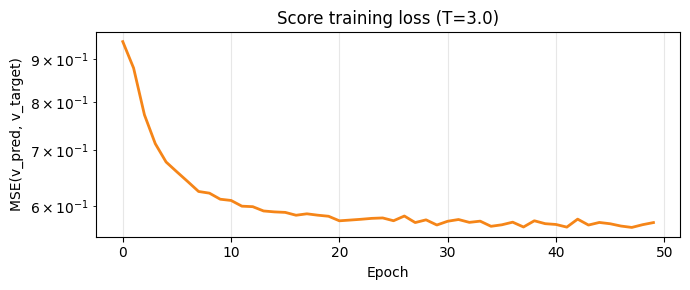

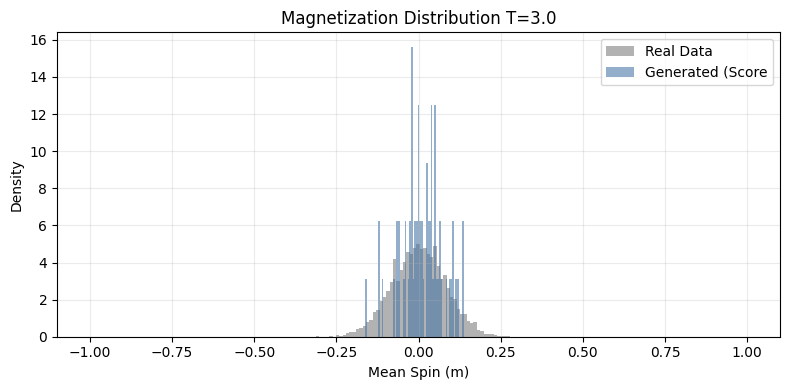

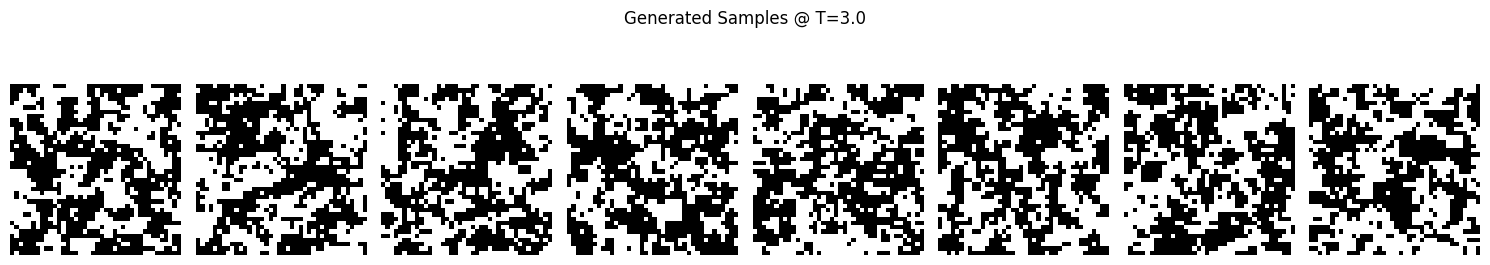

In [ ]:

def magnetization_per_sample(X_batch):
    return X_batch.mean(axis=1)

m_real = magnetization_per_sample(X)
m_gen = magnetization_per_sample(Xs)

# 4. Plot Loss
plt.figure(figsize=(7, 3))
plt.plot(score_losses, lw=2, color='#F58518')
plt.title(f"Score training loss (T={T_TRAIN_RAW})")
plt.xlabel("Epoch")
plt.ylabel("MSE(v_pred, v_target)")
plt.yscale("log")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 5. Plot Magnetization Distributions
plt.figure(figsize=(8, 4))
bins = 60
plt.hist(m_real, bins=bins, density=True, alpha=0.6, color='gray', label="Real Data")
plt.hist(m_gen,  bins=bins, density=True, alpha=0.6, color='#4C78A8', label="Generated (Score")
plt.title(f"Magnetization Distribution T={T_TRAIN_RAW}")
plt.xlabel("Mean Spin (m)")
plt.ylabel("Density")
plt.xlim(-1.1, 1.1)
plt.legend()
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

# 6. Visualize Sample Lattice Configurations
k = 8
plt.figure(figsize=(15, 3))
for i in range(k):
    plt.subplot(1, k, i + 1)
    plt.imshow(Xs[i].reshape(GRID, GRID), cmap="binary", vmin=-1, vmax=1)
    plt.axis("off")
plt.suptitle(f"Generated Samples @ T={T_TRAIN_RAW}")
plt.tight_layout()
plt.show()


Sampling 512 configs at T=1.0
Sampling 512 configs at T=2.269
Sampling 512 configs at T=3.5


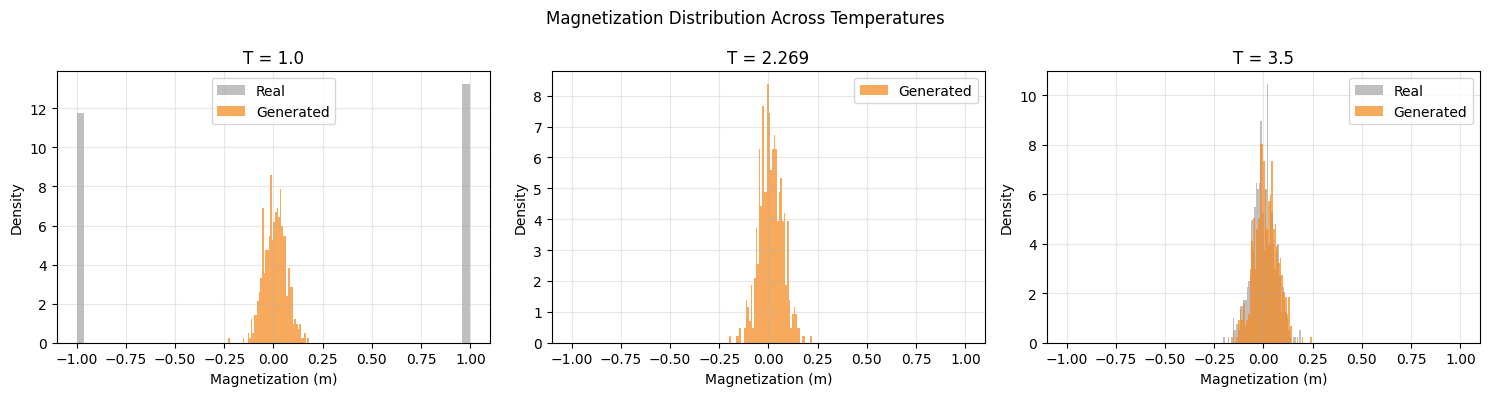

In [ ]:
test_temps = [1.0, 2.269, 3.5]
N_HIST_SAMPLES = 512

fig, axes = plt.subplots(1, len(test_temps), figsize=(15, 4))

for i, T_val in enumerate(test_temps):

    print(f"Sampling {N_HIST_SAMPLES} configs at T={T_val}")

    # --- Generated samples ---
    samples = sample_score_ddim(
        score_ema,
        T_raw=T_val,
        n=N_HIST_SAMPLES,
        steps=200,
        eta=0.8,
        discretize="end_sign"
    )

    m_gen = magnetization_per_sample(samples)

    # --- Real data at same temperature ---
    mask = np.isclose(Y_all, T_val, atol=1e-3)
    X_real_T = X_all[mask]

    if len(X_real_T) > 0:
        X_real_T = X_real_T[:N_HIST_SAMPLES]
        m_real = magnetization_per_sample(X_real_T)

        axes[i].hist(m_real, bins=50, density=True,
                     alpha=0.5, color='gray', label="Real")

    # --- Generated histogram ---
    axes[i].hist(m_gen, bins=50, density=True,
                 alpha=0.7, color='#F58518', label="Generated")

    axes[i].set_title(f"T = {T_val}")
    axes[i].set_xlim(-1.1, 1.1)
    axes[i].set_xlabel("Magnetization (m)")
    axes[i].set_ylabel("Density")
    axes[i].legend()
    axes[i].grid(alpha=0.3)

plt.suptitle("Magnetization Distribution Across Temperatures")
plt.tight_layout()
plt.show()
